In [18]:
fs = 1000
t = np.arange(-1, 1, 1/fs)
N = len(t)

print("Frecuencia de muestreo:", fs, "Hz")
print("Número de muestras:", N)

Frecuencia de muestreo: 1000 Hz
Número de muestras: 2000


In [19]:
pulso_rectangular = np.where(np.abs(t) <= 0.2, 1, 0)

escalon = np.where(t >= 0, 1, 0)

frecuencia_senoidal = 10
senoidal = np.sin(2 * np.pi * frecuencia_senoidal * t)


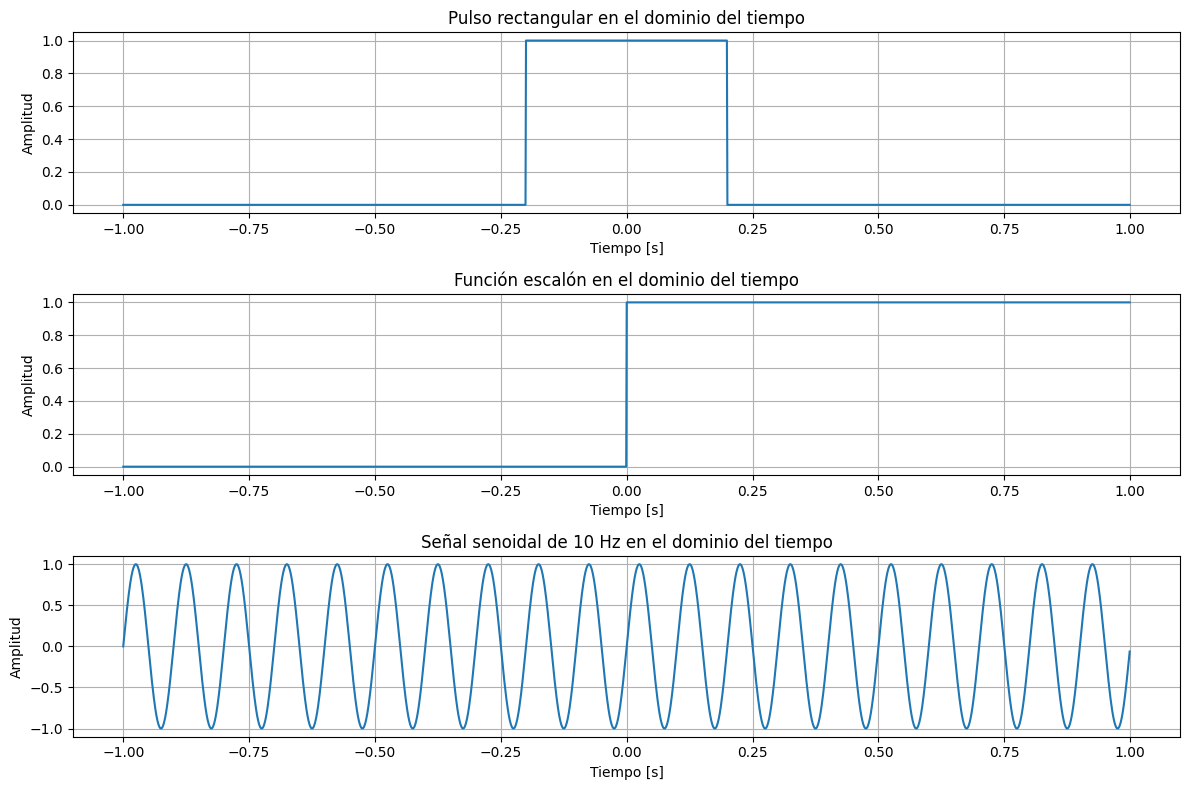

In [20]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, pulso_rectangular)
plt.title("Pulso rectangular en el dominio del tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, escalon)
plt.title("Función escalón en el dominio del tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, senoidal)
plt.title("Señal senoidal de 10 Hz en el dominio del tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
def calcular_fft(x, fs):
    N = len(x)

    X = np.fft.fft(x)
    X = np.fft.fftshift(X)
    X = X / N

    f = np.fft.fftfreq(N, d=1/fs)
    f = np.fft.fftshift(f)

    magnitud = np.abs(X)
    fase = np.angle(X)

    return f, magnitud, fase

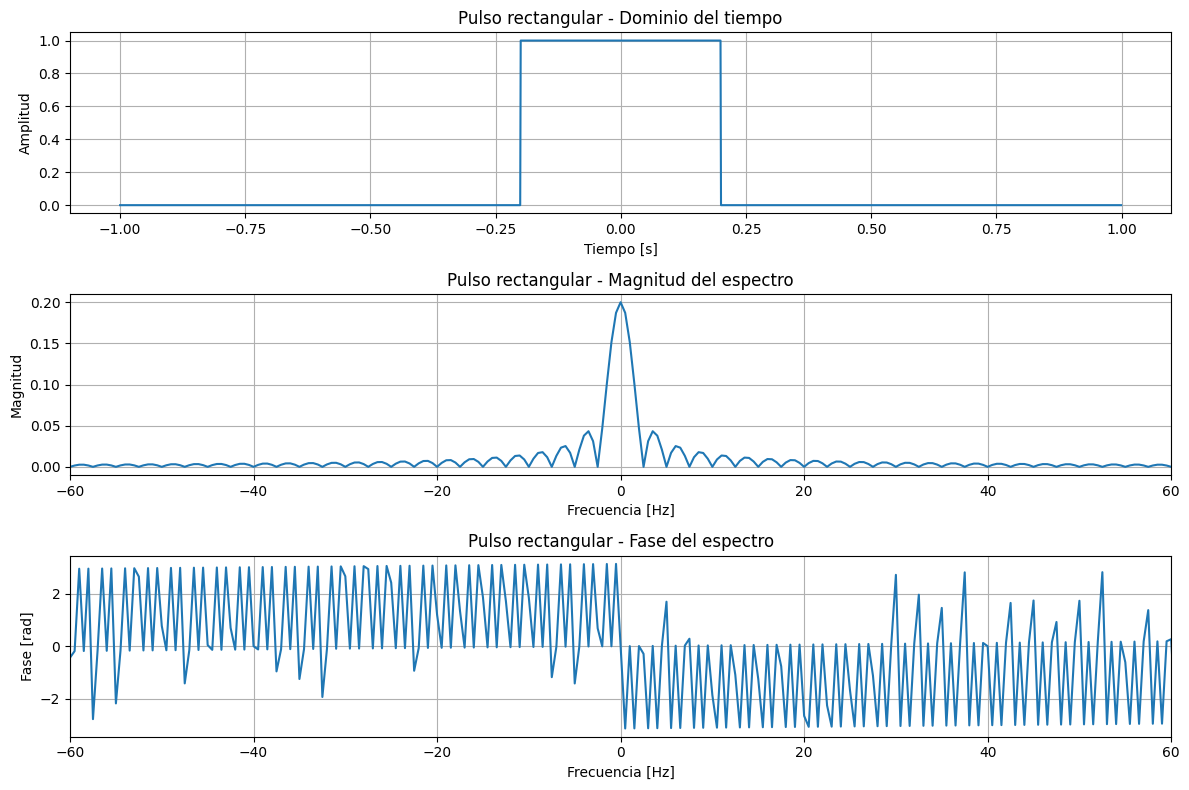

In [22]:
f, magnitud, fase = calcular_fft(pulso_rectangular, fs)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, pulso_rectangular)
plt.title("Pulso rectangular - Dominio del tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(f, magnitud)
plt.title("Pulso rectangular - Magnitud del espectro")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(-60, 60)
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(f, fase)
plt.title("Pulso rectangular - Fase del espectro")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.xlim(-60, 60)
plt.grid(True)

plt.tight_layout()
plt.show()

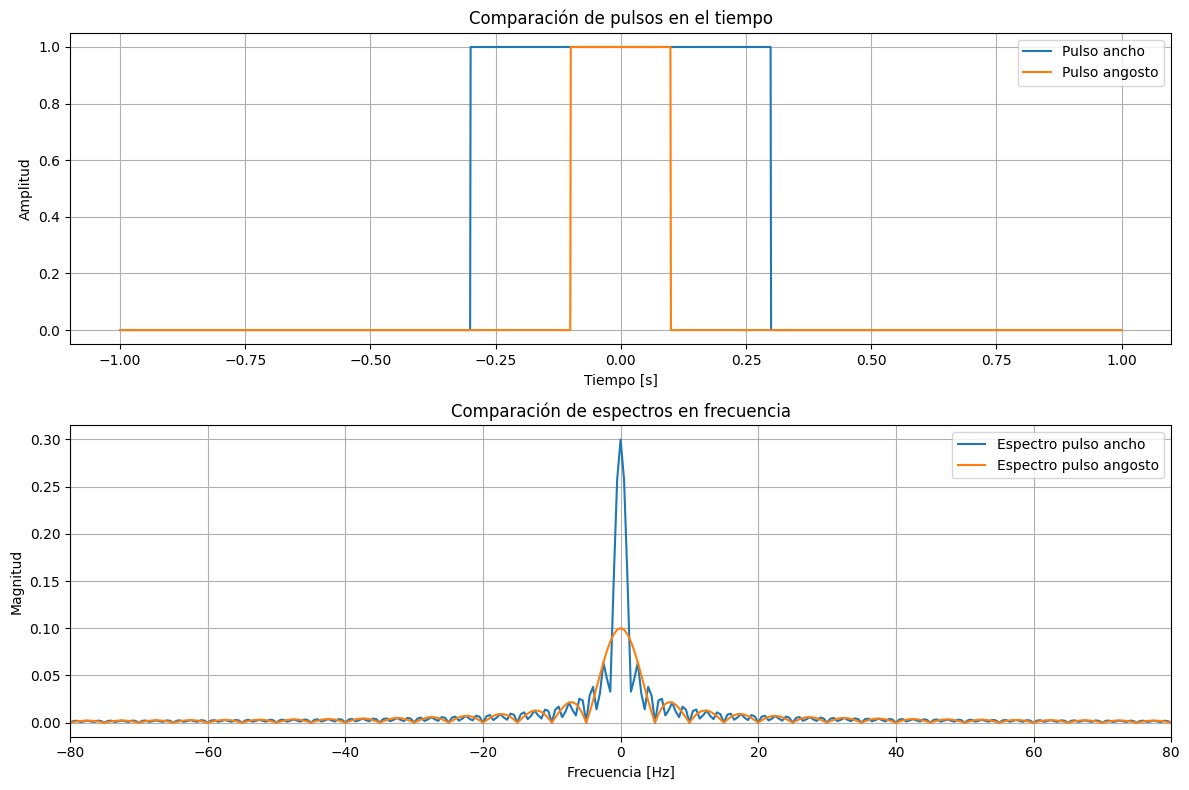

In [27]:
pulso_ancho = np.where(np.abs(t) <= 0.3, 1, 0)
pulso_angosto = np.where(np.abs(t) <= 0.1, 1, 0)

f1, mag_ancho, fase_ancho = calcular_fft(pulso_ancho, fs)
f2, mag_angosto, fase_angosto = calcular_fft(pulso_angosto, fs)

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t, pulso_ancho, label="Pulso ancho")
plt.plot(t, pulso_angosto, label="Pulso angosto")
plt.title("Comparación de pulsos en el tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(f1, mag_ancho, label="Espectro pulso ancho")
plt.plot(f2, mag_angosto, label="Espectro pulso angosto")
plt.title("Comparación de espectros en frecuencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(-80, 80)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

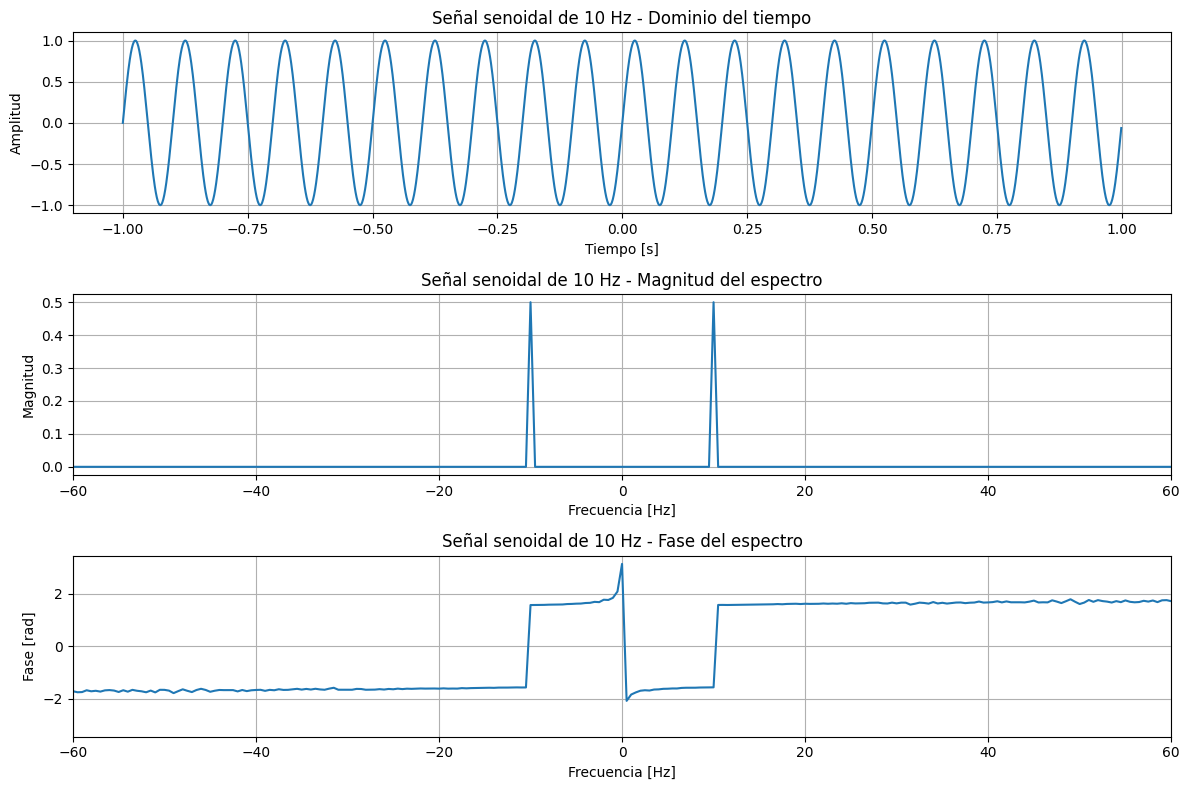

In [24]:
f, magnitud, fase = calcular_fft(senoidal, fs)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, senoidal)
plt.title("Señal senoidal de 10 Hz - Dominio del tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(f, magnitud)
plt.title("Señal senoidal de 10 Hz - Magnitud del espectro")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(-60, 60)
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(f, fase)
plt.title("Señal senoidal de 10 Hz - Fase del espectro")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.xlim(-60, 60)
plt.grid(True)

plt.tight_layout()
plt.show()

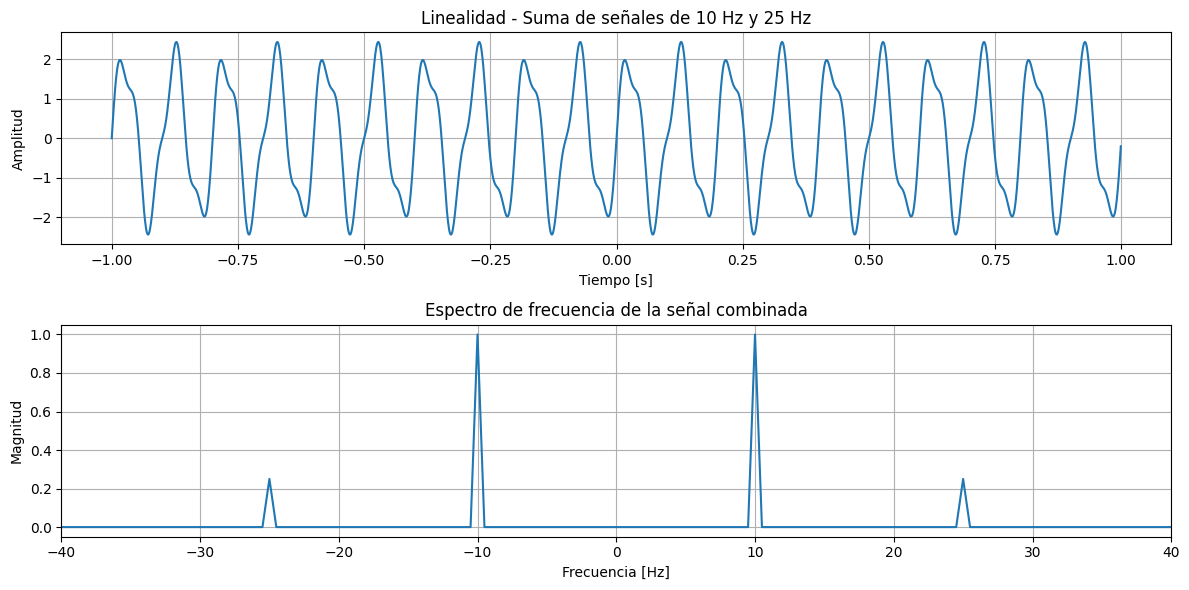

In [25]:
x1 = np.sin(2 * np.pi * 10 * t)
x2 = np.sin(2 * np.pi * 25 * t)

senal_lineal = 2*x1 + 0.5*x2

f, magnitud, fase = calcular_fft(senal_lineal, fs)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, senal_lineal)
plt.title("Linealidad - Suma de señales de 10 Hz y 25 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(f, magnitud)
plt.title("Espectro de frecuencia de la señal combinada")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(-40, 40)
plt.grid(True)

plt.tight_layout()
plt.show()

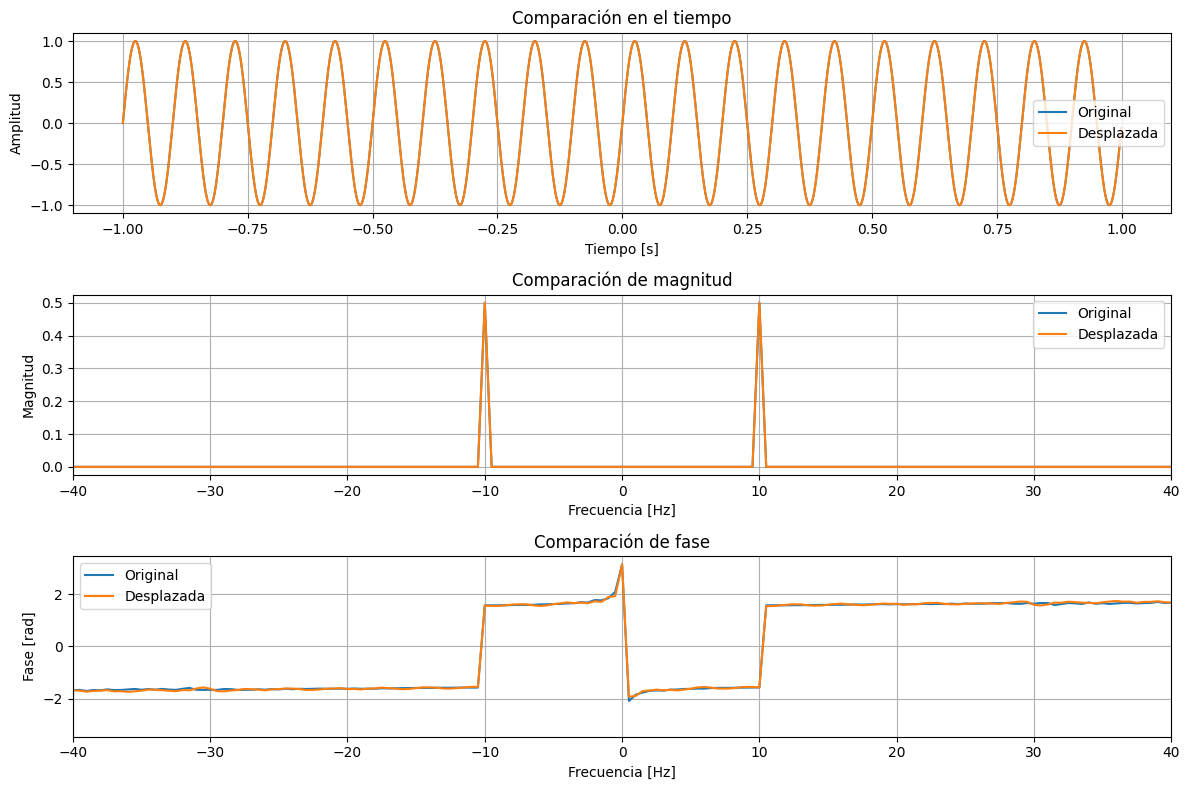

In [26]:
seno_original = np.sin(2 * np.pi * 10 * t)
seno_desplazado = np.sin(2 * np.pi * 10 * (t - 0.2))

f1, mag_original, fase_original = calcular_fft(seno_original, fs)
f2, mag_desplazada, fase_desplazada = calcular_fft(seno_desplazado, fs)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, seno_original, label="Original")
plt.plot(t, seno_desplazado, label="Desplazada")
plt.title("Comparación en el tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(f1, mag_original, label="Original")
plt.plot(f2, mag_desplazada, label="Desplazada")
plt.title("Comparación de magnitud")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(-40, 40)
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(f1, fase_original, label="Original")
plt.plot(f2, fase_desplazada, label="Desplazada")
plt.title("Comparación de fase")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.xlim(-40, 40)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

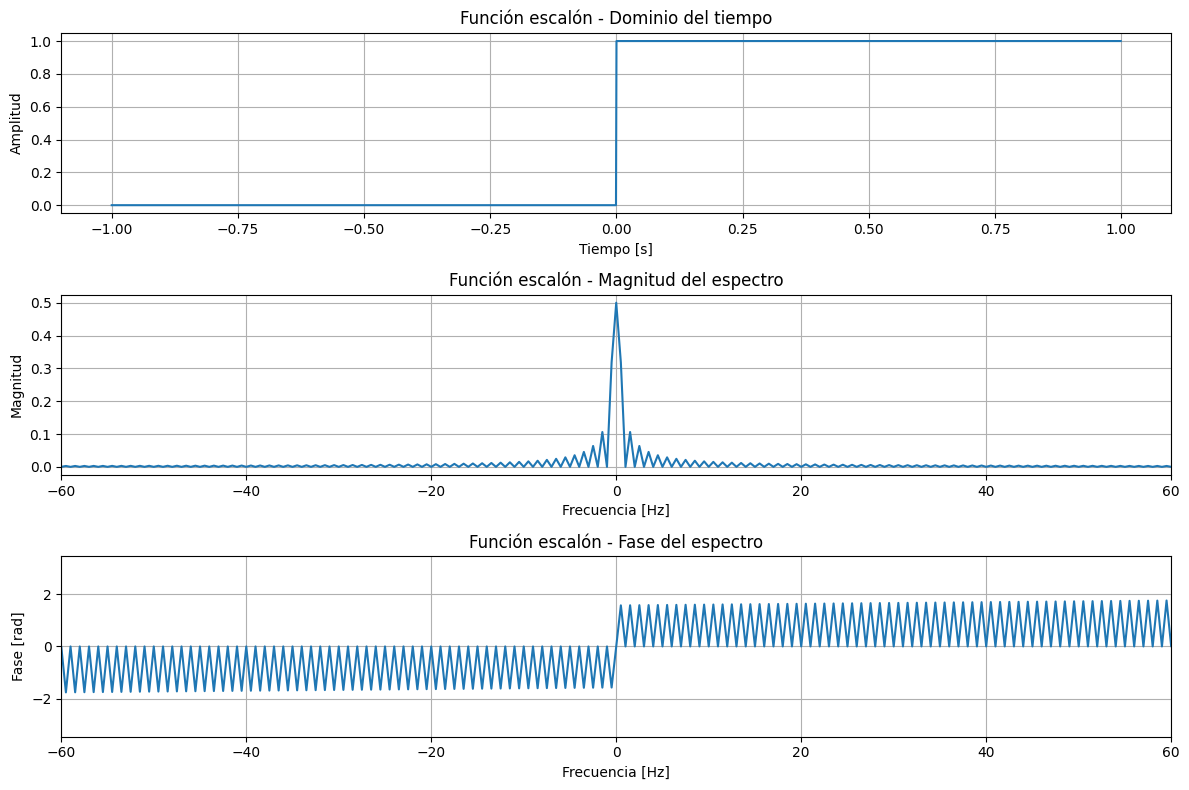

In [23]:
f, magnitud, fase = calcular_fft(escalon, fs)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, escalon)
plt.title("Función escalón - Dominio del tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(f, magnitud)
plt.title("Función escalón - Magnitud del espectro")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(-60, 60)
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(f, fase)
plt.title("Función escalón - Fase del espectro")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.xlim(-60, 60)
plt.grid(True)

plt.tight_layout()
plt.show()